# Biomarcador 1 - Latencia de Arranque

In [100]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from routines import rellenar_muestras

plt.rcParams["figure.figsize"] = (20,6)

df = pd.read_parquet("/Users/Ana/20250507_132315.parquet")


## Rutinas

In [101]:
from numpy import array, ndarray, sqrt
from scipy.signal import convolve


#df = df.rename(columns={"timestamp": "ts", "stimuli_x": "sx", "stimuli_y": "sy", "eyes_x": "ex", "eyes_y": "ey"})


def distance(x, y):
    """
    Calcula la distancia entre dos puntos en un espacio 2D (vector desplazamiento).

    Args:
        x (ndarray): Coordenadas x de los puntos.
        y (ndarray): Coordenadas y de los puntos.

    Returns:
        ndarray: Distancia entre los puntos.
    """
    x_prev = x[:-1]
    x_curr = x[1:]
    y_prev = y[:-1]
    y_curr = y[1:]
    return sqrt((x_prev - x_curr) ** 2 + (y_prev - y_curr) ** 2)


def differentiate(channel):
    window = array([300, -294, -532, -503, -296, 0, 296, 503, 532, 294, -300])
    result = convolve(channel, window, "same") / 5148.0
    result[:5] = 0
    result[-5:] = 0
    return result * 1000




In [102]:

#df = df.rename(columns={"timestamp": "ts", "stimuli_x": "sx", "stimuli_y": "sy", "eyes_x": "ex", "eyes_y": "ey"})
rellenado = rellenar_muestras(df)

distance_e = distance(rellenado["eyes_x"], rellenado["eyes_y"])

time = rellenado["timestamp"][1:-1]
distance_e = distance_e.values[1:-1]


## Latencia de arranque

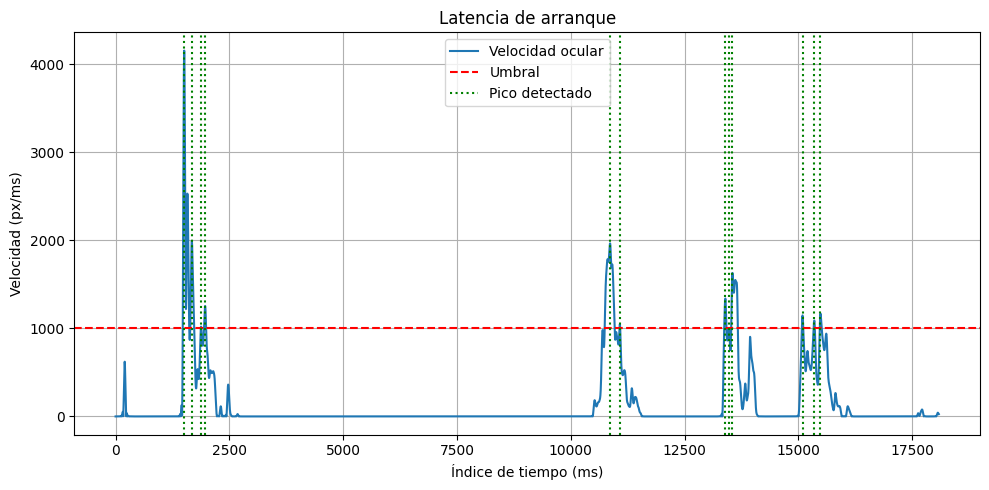

In [103]:
from scipy import signal
from typing import Iterator

def denoise_35(channel: np.ndarray) -> np.ndarray:
    """Remove high frequency noise from the channel

    Args:
        channel (ndarray): Channel

    Returns:
        ndarray: Channel
    """
    # Hacemos un filtrado agresivo ya que lo que nos interesa es la forma de onda
    # en general de la señal para identificar el desfase
    b, a = signal.butter(3, 0.035)
    y = signal.filtfilt(b, a, channel)
    return y

def find_peaks(vel: np.ndarray, threshold: float) -> Iterator[int]:
    max_idx = None
    max_value = None
    for idx, sample in enumerate(vel):
        if sample < threshold:
            if max_idx is not None:
                yield max_idx
                
            max_idx = None
            max_value = None
            continue

        if max_idx is None or sample > max_value:
            max_idx = idx
            max_value = sample

    if max_idx is not None:
        yield max_idx




from scipy.signal import medfilt
THRESHOLD = 1000
START = 100
END = rellenado.shape[0]

eyes_x = rellenado["eyes_x"].values.astype(np.int32)
eyes_y = rellenado["eyes_y"].values.astype(np.int32)

dis = distance(eyes_x, eyes_y)[1:-1]
vel = abs(differentiate(dis))
# vel = medfilt(vel, 31)
vel = abs(denoise_35(vel))
peaks = list(find_peaks(vel, threshold=THRESHOLD))

# --- Plot con etiquetas y leyenda
plt.figure(figsize=(10, 5))
plt.plot(vel[START:END], label="Velocidad ocular")
plt.axhline(THRESHOLD, color="r", linestyle="--", label="Umbral")


for peak in peaks:
    p = peak - START
    if 0 <= p <= (END - START):
        plt.axvline(p, color='g', linestyle=':', label="Pico detectado")

# Evitar etiquetas duplicadas en la leyenda
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

# Añadir título y etiquetas
plt.title("Latencia de arranque")
plt.xlabel("Índice de tiempo (ms)")
plt.ylabel("Velocidad (px/ms)")
plt.grid(True)
plt.tight_layout()
plt.show()  


## Velocidad media de alineación

Comparo la velocidad media de alineación (de todo el experimento), con la velocidad ocular en cada momento

Velocidad media general de alineación: 144.09 px/ms


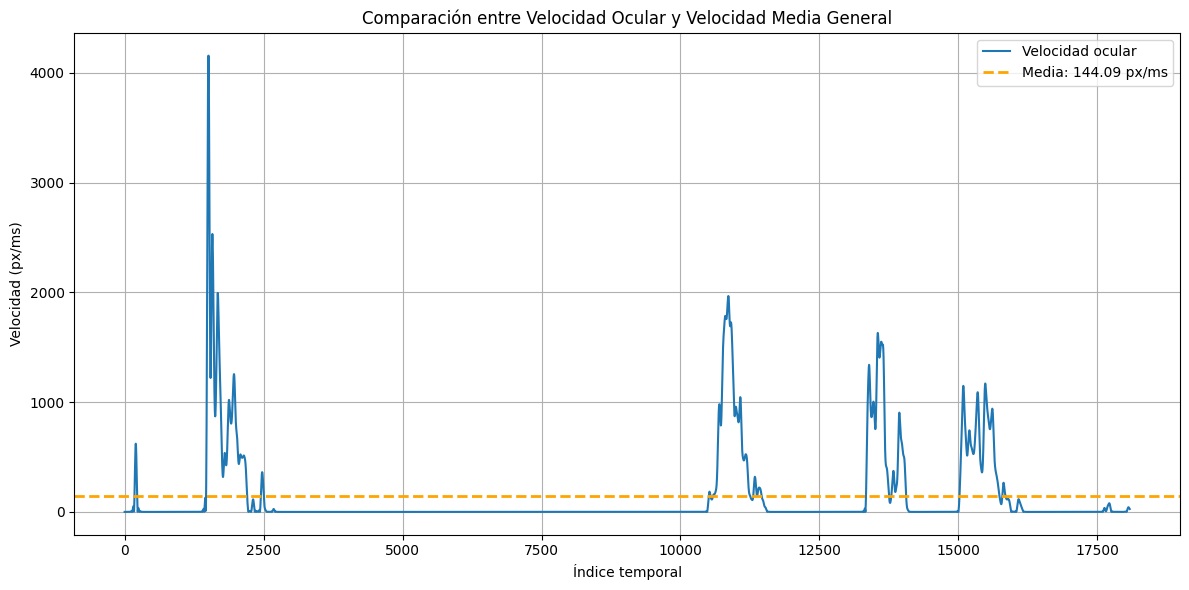

In [104]:
# Calcular velocidad media general
media_vel_general = np.mean(vel)
print(f"Velocidad media general de alineación: {media_vel_general:.2f} px/ms")

# --- Plot comparativo
plt.figure(figsize=(12, 6))

# Señal de velocidad ocular
plt.plot(vel[START:END], label="Velocidad ocular")

# Línea de velocidad media
plt.axhline(media_vel_general, color="orange", linestyle="--", linewidth=2,
            label=f"Media: {media_vel_general:.2f} px/ms")

# Etiquetas y formato
plt.title("Comparación entre Velocidad Ocular y Velocidad Media General")
plt.xlabel("Índice temporal")
plt.ylabel("Velocidad (px/ms)")
plt.legend(loc="upper right")
plt.grid(True)
plt.tight_layout()
plt.show()


In [105]:
rellenado[40:60]

,timestamp,stimuli_x,stimuli_y,stimuli_color,eyes_x,eyes_y,key
40,1746616977426,0,0,16777215,1011,443,0
41,1746616977427,0,0,16777215,1011,443,0
42,1746616977428,0,0,16777215,1011,443,0
43,1746616977429,0,0,16777215,1011,443,0
44,1746616977430,0,0,16777215,1011,443,0
45,1746616977431,0,0,16777215,1011,443,0
46,1746616977432,0,0,16777215,1011,443,0
47,1746616977433,0,0,16777215,1011,443,0
48,1746616977434,0,0,16777215,1011,443,0
49,1746616977435,0,0,16777215,1011,443,0


## Velocidad media al exceder el umbral 

Velocidad media en los segmentos en los que se ha excedido el umbral de velocidad (threshold = 1000).  
Para mejor compresión, la gráfica se representa desde el umbral, ignorando los valores por debajo de él

Velocidad media en segmentos que superan el umbral: 1566.82 px/ms


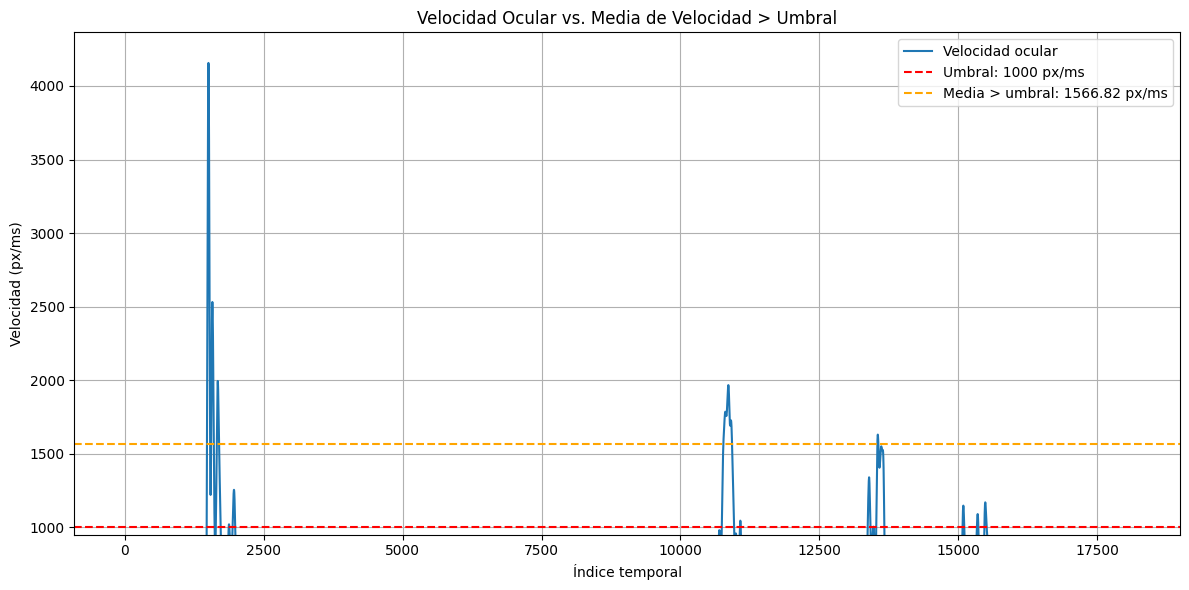

In [107]:
# Calcular media de velocidad solo cuando se supera el umbral
vel_superior_umbral = vel[vel > THRESHOLD]
media_vel_superior = np.mean(vel_superior_umbral)
print(f"Velocidad media en segmentos que superan el umbral: {media_vel_superior:.2f} px/ms")

# --- Plot comparativo
plt.figure(figsize=(12, 6))

# Señal de velocidad ocular
plt.plot(vel[START:END], label="Velocidad ocular")

# Umbral
plt.axhline(THRESHOLD, color="red", linestyle="--", label=f"Umbral: {THRESHOLD} px/ms")

# Media sobre los segmentos por encima del umbral
plt.axhline(media_vel_superior, color="orange", linestyle="--", linewidth=1.5,
            label=f"Media > umbral: {media_vel_superior:.2f} px/ms")

# Solo mostrar desde justo debajo del umbral hasta el valor máximo
plt.ylim(THRESHOLD * 0.95, np.max(vel) * 1.05)

# Etiquetas y formato
plt.title("Velocidad Ocular vs. Media de Velocidad > Umbral")
plt.xlabel("Índice temporal")
plt.ylabel("Velocidad (px/ms)")
plt.legend(loc="upper right")
plt.grid(True)
plt.tight_layout()
plt.show()
